# Background

Walmart is a renowned retail corporation that operates a chain of hypermarkets. Here, Walmart has provided a data combining of 45 stores including store information and monthly sales. The data is provided on weekly basis. Walmart tries to find the impact of holidays on the sales of store. For which it has included four holidays’ weeks into the dataset which are Christmas, Thanksgiving, Super bowl, Labor Day. Here we are owing to Analyze the dataset given. Before doing that, let me point out the objective of this analysis.

# Business Objectives
Our Main Objective is to predict sales of store in a week. As in dataset size and time related data are given as feature, so analyze if sales are impacted by time-based factors and space- based factor. Most importantly how inclusion of holidays in a week soars the sales in store?

## Importing Necessary Libraries and Data

In [18]:
import pandas as pd
import numpy as np 
import seaborn as sns 
train = pd.read_csv(r"C:\Users\faroo\OneDrive\FAROOK\OneDrive\MY DATA\DA Resume\train.csv")
features = pd.read_csv(r"C:\Users\faroo\OneDrive\FAROOK\OneDrive\MY DATA\DA Resume\features.csv")
stores = pd.read_csv(r"C:\Users\faroo\OneDrive\FAROOK\OneDrive\MY DATA\DA Resume\stores.csv")

## Converting date columns to datetime

In [20]:
train['Date'] = pd.to_datetime(train['Date'])
features['Date'] = pd.to_datetime(features['Date'])

## Merge datasets

In [26]:
df = pd.merge(train, features, how='left', on=['Store', 'Date'])
df = pd.merge(df, stores, how='left', on='Store')

## Fill missing markdowns with 0

In [29]:
markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']
df[markdown_cols] = df[markdown_cols].fillna(0)


## Feature Engineering

In [27]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week

## Total markdown amount column and & Check for duplicates or erroneous data

In [33]:

df['TotalMarkdown'] = df[markdown_cols].sum(axis=1)

In [35]:

print(f"Duplicate rows count: {df.duplicated().sum()}")
df = df.drop_duplicates()

Duplicate rows count: 0


## Exploratory Data Analysis (EDA)
## Overall sales statistics

In [38]:

print("Sales Statistics:")
print(df['Weekly_Sales'].describe())

Sales Statistics:
count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64


## Plot total weekly sales over time

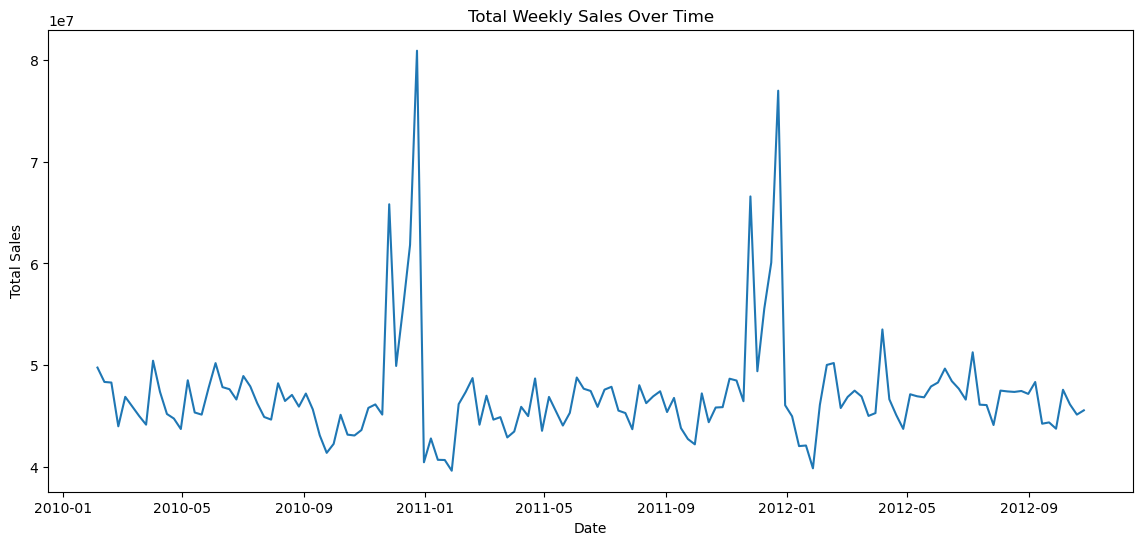

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

weekly_sales = df.groupby('Date')['Weekly_Sales'].sum().reset_index()
plt.figure(figsize=(14,6))
sns.lineplot(data=weekly_sales, x='Date', y='Weekly_Sales')
plt.title('Total Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()


## Sales distribution across stores

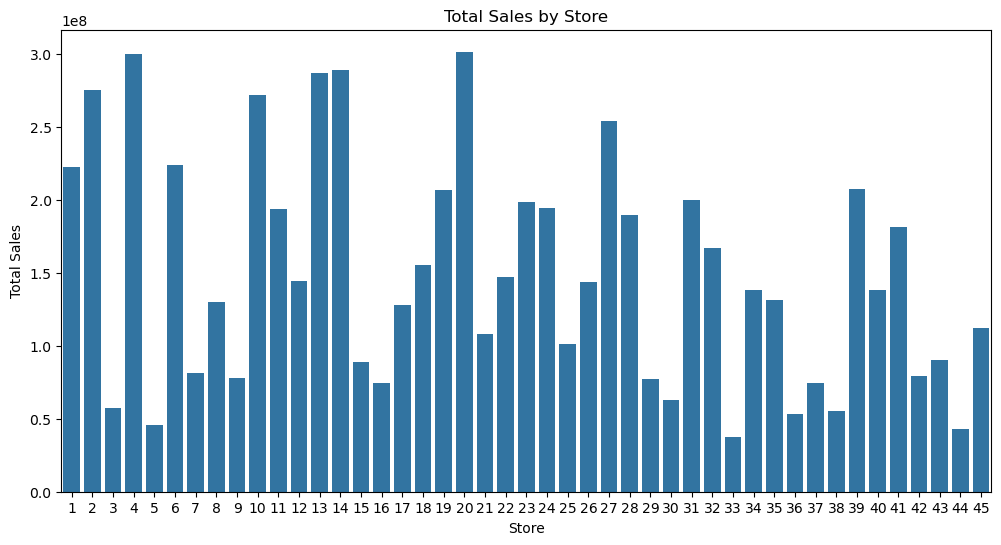

In [48]:
# Sales distribution across stores
sales_by_store = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(x=sales_by_store.index, y=sales_by_store.values)
plt.title('Total Sales by Store')
plt.xlabel('Store')
plt.ylabel('Total Sales')
plt.show()

## Sales by store type

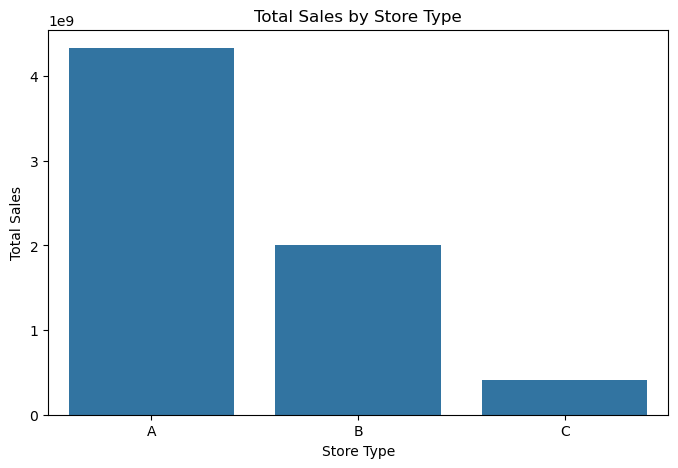

In [39]:
sales_by_type = df.groupby('Type')['Weekly_Sales'].sum()
plt.figure(figsize=(8,5))
sns.barplot(x=sales_by_type.index, y=sales_by_type.values)
plt.title('Total Sales by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Total Sales')
plt.show()

In [43]:
print (df.columns)

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday_x', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_y', 'Type', 'Size',
       'Year', 'Month', 'Week', 'TotalMarkdown'],
      dtype='object')


## Is Holiday Column 

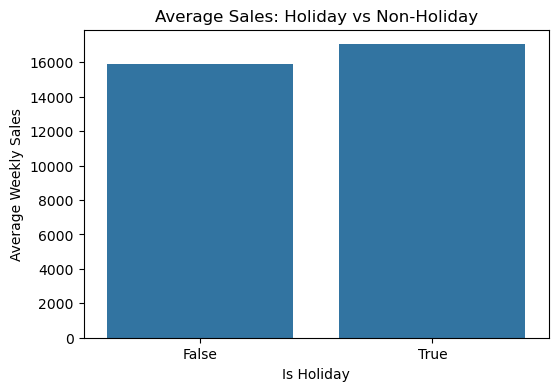

In [45]:
holiday_sales = df.groupby('IsHoliday_x')['Weekly_Sales'].mean().reset_index()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(x='IsHoliday_x', y='Weekly_Sales', data=holiday_sales)
plt.title('Average Sales: Holiday vs Non-Holiday')
plt.xlabel('Is Holiday')
plt.ylabel('Average Weekly Sales')
plt.show()


## Correlation Heatmap to examine relationships

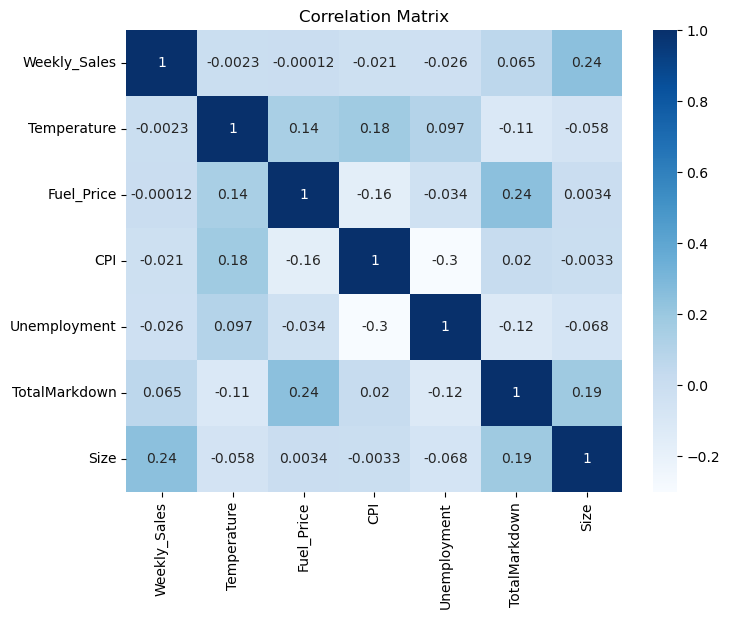

In [47]:

corr_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'TotalMarkdown', 'Size']
corr = df[corr_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title('Correlation Matrix')
plt.show()

In [49]:
# Top 5 stores by sales
top_5_stores = sales_by_store.head()
print(f"Top 5 stores by total sales:\n{top_5_stores}")

Top 5 stores by total sales:
Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
Name: Weekly_Sales, dtype: float64


In [51]:
# Average sales per department
sales_by_dept = df.groupby('Dept')['Weekly_Sales'].mean().sort_values(ascending=False)
print("Top 5 departments by average sales:")
print(sales_by_dept.head())

Top 5 departments by average sales:
Dept
92    75204.870531
95    69824.423080
38    61090.619568
72    50566.515417
65    45441.706224
Name: Weekly_Sales, dtype: float64


## Rolling Average for smoothing weekly sales trends for a store

In [53]:

store_sample = 1
store_sales = df[df['Store'] == store_sample].sort_values('Date')
store_sales.set_index('Date', inplace=True)
store_sales['RollingMean_4week'] = store_sales['Weekly_Sales'].rolling(window=4).mean()

In [57]:

duplicate_dates = store_sales.index[store_sales.index.duplicated()]
print(f"Duplicate dates: {duplicate_dates}")

Duplicate dates: DatetimeIndex(['2010-02-05', '2010-02-05', '2010-02-05', '2010-02-05',
               '2010-02-05', '2010-02-05', '2010-02-05', '2010-02-05',
               '2010-02-05', '2010-02-05',
               ...
               '2012-10-26', '2012-10-26', '2012-10-26', '2012-10-26',
               '2012-10-26', '2012-10-26', '2012-10-26', '2012-10-26',
               '2012-10-26', '2012-10-26'],
              dtype='datetime64[ns]', name='Date', length=10101, freq=None)


In [59]:
store_sales = store_sales.groupby(store_sales.index).agg({'Weekly_Sales': 'sum'}).reset_index()
store_sales.set_index('Date', inplace=True)
store_sales['RollingMean_4week'] = store_sales['Weekly_Sales'].rolling(window=4).mean()

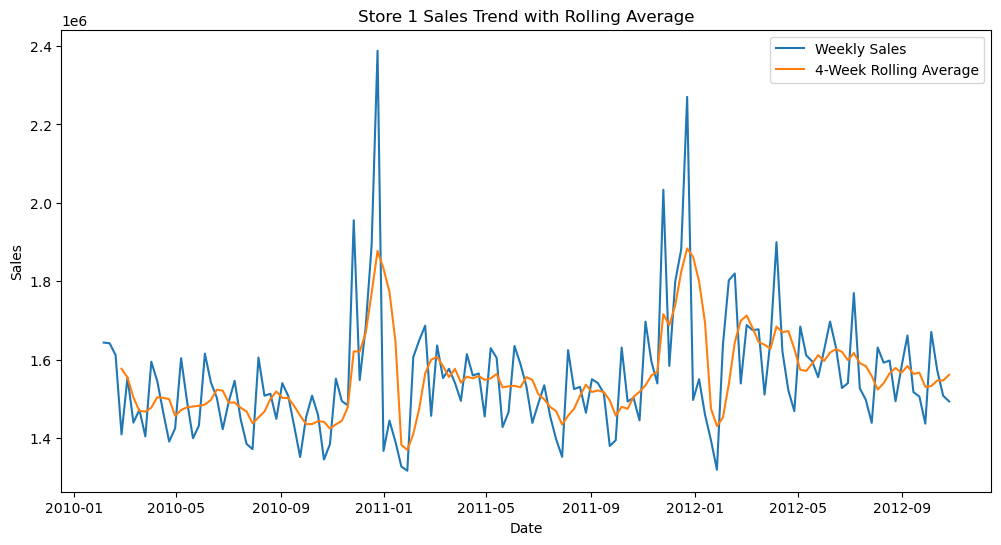

In [61]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=store_sales, x=store_sales.index, y='Weekly_Sales', label='Weekly Sales')
sns.lineplot(data=store_sales, x=store_sales.index, y='RollingMean_4week', label='4-Week Rolling Average')
plt.title(f'Store {store_sample} Sales Trend with Rolling Average')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

In [63]:
# Export cleaned and feature-enhanced data for Power BI
df.to_csv('walmart_sales_analysis_cleaned.csv', index=False)
print("Cleaned and processed data exported to walmart_sales_analysis_cleaned.csv")

Cleaned and processed data exported to walmart_sales_analysis_cleaned.csv
